# Evaluación Parcial 1: Sistema Especializado de Patologías en Tomate

**Asignatura:** Tecnicas Avanzadas de Machine Learning (TLY1102)

**Sección:** 001D

**Integrantes:**
- Matías Gutiérrez
- David Larenas
- Victor Mena

## Fase 0: Comprensión del Negocio

Para este caso (dataset PlantVillage) generaremos una variante del problema para concentrar el modelo unicamente en el cultivo de tomate, descartando demas clases (papa y pimentón).

La razón detras de esto, es que el tomate representa el cultivo con mayor diversidad de enfermedades (tal como se demuestra en el dataset). Al eliminar los demas cultivos, reducimos el ruido que podriamos tener, y esto es sumamente util para que el Perceptron Multicapa logre distingir con mayor efectividad, utilizando toda su capacidad vectorial en determinar patrones pequeños en una misma planta (tomate en este caso).

## Fase 1: Carga y Preparación de Datos

### Descompresión del Dataset
Como el conjunto de datos viene en un archivo comprimido (.zip), debemos descomprimir y extrae todas las fotos en una carpeta de trabajo para que podamos utilizarlas.

In [1]:
!unzip -o -q "/content/PlantVillage Dataset.zip" -d "/content/data"

### Importaciones de Librerias

In [90]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

### Carga de Dataset
Empezamos, cargando el dataset de imagenes con un split 80/20. con sus respectivas clases.

In [41]:
clases_variante = ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']

train_ds = tf.keras.utils.image_dataset_from_directory(
    './data/PlantVillage',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32,
    class_names=clases_variante
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    './data/PlantVillage',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32,
    class_names=clases_variante
)

clases = train_ds.class_names

print("\nClases:", clases)

Found 16011 files belonging to 10 classes.
Using 12809 files for training.
Found 16011 files belonging to 10 classes.
Using 3202 files for validation.

Clases: ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


### Grafico del Balance de las Clases del Dataset

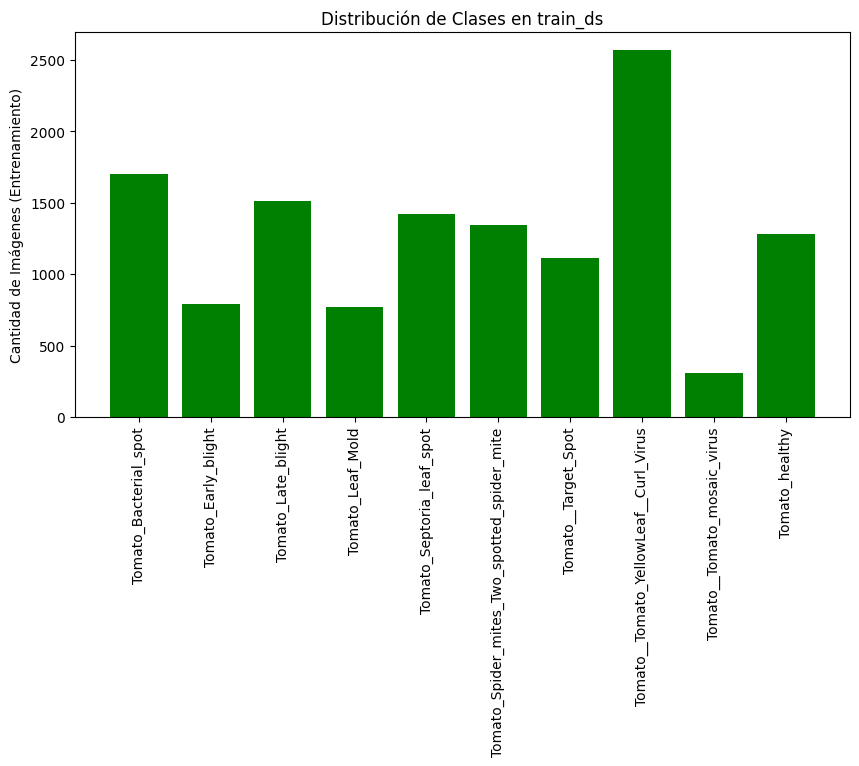

In [42]:
etiquetas = np.concatenate([y.numpy() for x, y in train_ds])

_, image_counts = np.unique(etiquetas, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(clases, image_counts, color='green')
plt.xticks(rotation=90)
plt.ylabel('Cantidad de Imágenes (Entrenamiento)')
plt.title('Distribución de Clases en train_ds')
plt.show()

El gráfico evidencia un claro desbalance entre las 10 clases: Tomato__Tomato_YellowLeaf_Curl_Virus domina con más de 2.500 imágenes, mientras que mosaic_virus apenas alcanza 300. Este desequilibrio corre el riesgo de sesgar al modelo a predecir con mayor frecuencia la categoría mayoritaria.

### 3. Visualización de Muestras
Generamos una cuadrícula con algunas de las fotos ya procesadas. Esto nos sirve para confirmar visualmente que el sistema cargó las imágenes correctamente y que las etiquetas coinciden con las imagenes dispuestas.

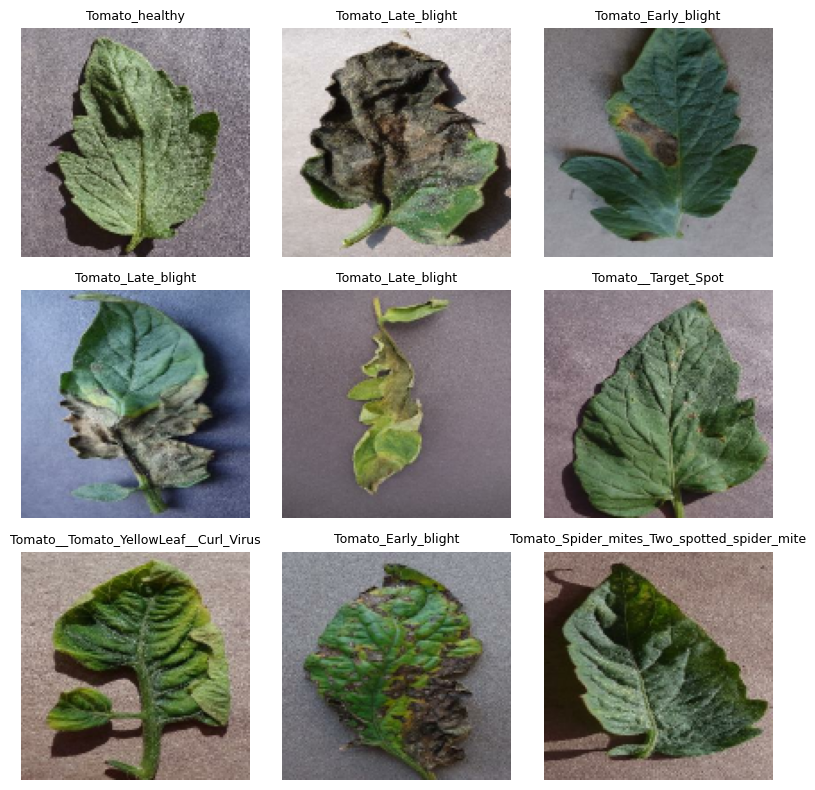

In [89]:
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(clases[labels[i].numpy()], fontsize=9)
        plt.axis("off")
plt.tight_layout()
plt.show()

Las imágenes confirman que la carga y el preprocesamiento de los datos se realizaron de forma correcta, verificando que los nombres de las etiquetas coinciden adecuadamente con la fotografía mostrada. Se observa claramente la diferencia entre hojas sanas, las cuales lucen completamente verdes, y hojas enfermas como Tomato_Leaf_Mold, las cuales presentan manchas amarillas y deterioro visible. Además, el encuadre centrado y los fondos neutros estandarizados benefician el entrenamiento al reducir distracciones visuales, permitiendo que la red se enfoque únicamente en la estructura y textura de la hoja.

### 2. Preprocesamiento
Aquí preparamos las imagenes para el MLP:
1. Ajustamos todas las imagenes al mismo tamaño (128x128).
2. Las dividimos en un grupo para entrenamiento y otro para validar.

In [83]:
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

## Fase 2: Modelado y Entrenamiento

### Arquitectura del Modelo (A)

En esta arquitectura tenemos una sola capa oculta con 64 neuronas ReLU para procesar el vector de 49152 entradas, es probable que colapse en el aprendizaje (underfitting).

#### Definición de la Arquitectura del Modelo

In [84]:
modelo_a = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(len(clases), activation='softmax')
])

modelo_a.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_7 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 64)             │     3,145,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,146,442 (12.00 MB)

 Trainable params: 3,146,442 (12.00 MB)

 Non-trainable params: 0 (0.00 B)

#### Compilación del modelo

In [85]:
modelo_a.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Entrenamiento del modelo

In [68]:
historia_a = modelo_a.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.1803 - loss: 2.9709 - val_accuracy: 0.2005 - val_loss: 2.2496
Epoch 2/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.2003 - loss: 2.2340 - val_accuracy: 0.2005 - val_loss: 2.2164
Epoch 3/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.2003 - loss: 2.2123 - val_accuracy: 0.2005 - val_loss: 2.2016
Epoch 4/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.2003 - loss: 2.2032 - val_accuracy: 0.2005 - val_loss: 2.1953
Epoch 5/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.2003 - loss: 2.1996 - val_accuracy: 0.2005 - val_loss: 2.1925
Epoch 6/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.2003 - loss: 2.1981 - val_accuracy: 0.2005 - val_loss: 2.1911
Epoch 7/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.2003 - loss: 2.1975 - val_accuracy: 0.2005 - val_loss: 2.1903
Epoch 8/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.2003 - loss: 2.1972 - 

### Arquitectura del Modelo (B)

En esta arquitectura tenemos una 3 capas ocultas con 512, 256 y 128 neuronas con activación ReLU para procesar el vector de 49152 entradas, es una arquitectura mucho mas potente en comparación a la anterior arquitectura, es muy probable que logre un alto rendimiento y desempeño en entrenamiento y validación.

#### Definición de la Arquitectura del Modelo

In [71]:
modelo_b = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(clases), activation='softmax')
])

modelo_b.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 512)            │    25,166,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,331,850 (96.63 MB)

 Trainable params: 25,331,850 (96.63 MB)

 Non-trainable params: 0 (0.00 B)

#### Compilación del modelo

In [72]:
modelo_b.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Entrenamiento del modelo

In [73]:
historia_b = modelo_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.3868 - loss: 2.8698 - val_accuracy: 0.5462 - val_loss: 1.4465
Epoch 2/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.5395 - loss: 1.3743 - val_accuracy: 0.6087 - val_loss: 1.1551
Epoch 3/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.6045 - loss: 1.1859 - val_accuracy: 0.6521 - val_loss: 1.0104
Epoch 4/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.6276 - loss: 1.1012 - val_accuracy: 0.6621 - val_loss: 0.9971
Epoch 5/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.6711 - loss: 0.9741 - val_accuracy: 0.6093 - val_loss: 1.2681
Epoch 6/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.6884 - loss: 0.9069 - val_accuracy: 0.6546 - val_loss: 0.9888
Epoch 7/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.6990 - loss: 0.8731 - val_accuracy: 0.6780 - val_loss: 0.9155
Epoch 8/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.7198 - loss: 0.8092 - 

### Arquitectura del Modelo (C)

En esta arquitectura tenemos unas 2 capas ocultas con 256 y 128 neuronas con activación ReLU para procesar el vector de 49152 entradas, es una arquitectura balanceada, es probable que logre un rendimiento y desempeño aceptables en el entrenamiento y validación.

#### Definición de la Arquitectura del Modelo

In [74]:
modelo_c = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(clases), activation='softmax')
])

modelo_c.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 256)            │    12,583,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,617,354 (48.13 MB)

 Trainable params: 12,617,354 (48.13 MB)

 Non-trainable params: 0 (0.00 B)

#### Compilación del modelo

In [75]:
modelo_c.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Entrenamiento del modelo

In [76]:
historia_c = modelo_c.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.3801 - loss: 3.0550 - val_accuracy: 0.4697 - val_loss: 1.4831
Epoch 2/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.5235 - loss: 1.4176 - val_accuracy: 0.5934 - val_loss: 1.2019
Epoch 3/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.5794 - loss: 1.2472 - val_accuracy: 0.4791 - val_loss: 1.5332
Epoch 4/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.6084 - loss: 1.1566 - val_accuracy: 0.6193 - val_loss: 1.1191
Epoch 5/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.6462 - loss: 1.0410 - val_accuracy: 0.6555 - val_loss: 1.0218
Epoch 6/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.6681 - loss: 0.9683 - val_accuracy: 0.6749 - val_loss: 0.9435
Epoch 7/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.6727 - loss: 0.9608 - val_accuracy: 0.6658 - val_loss: 0.9560
Epoch 8/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.6967 - loss: 0.8806 - v

## Fase 3: Evaluación

### Graficación de Rendimiento de Modelos (accuracy y loss)

Definimos una función para graficar el rendimiento de cada arquitectura de modelo entrenada y asi evaluar que tal fué su rendimiento teniendo información mas visual y legible para nosotros.

In [77]:
def graficar_rendimiento(historia, nombre_arquitectura):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(historia.history['loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    ax1.plot(historia.history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2)
    ax1.set_title(f'Pérdida (Loss) - {nombre_arquitectura}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Pérdida')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2.plot(historia.history['accuracy'], label='Train Accuracy', color='#1f77b4', linewidth=2)
    ax2.plot(historia.history['val_accuracy'], label='Val Accuracy', color='#ff7f0e', linewidth=2)
    ax2.set_title(f'Precisión (Accuracy) - {nombre_arquitectura}', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Precisión')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

#### Grafico de Rendimiento: Arquitectura A

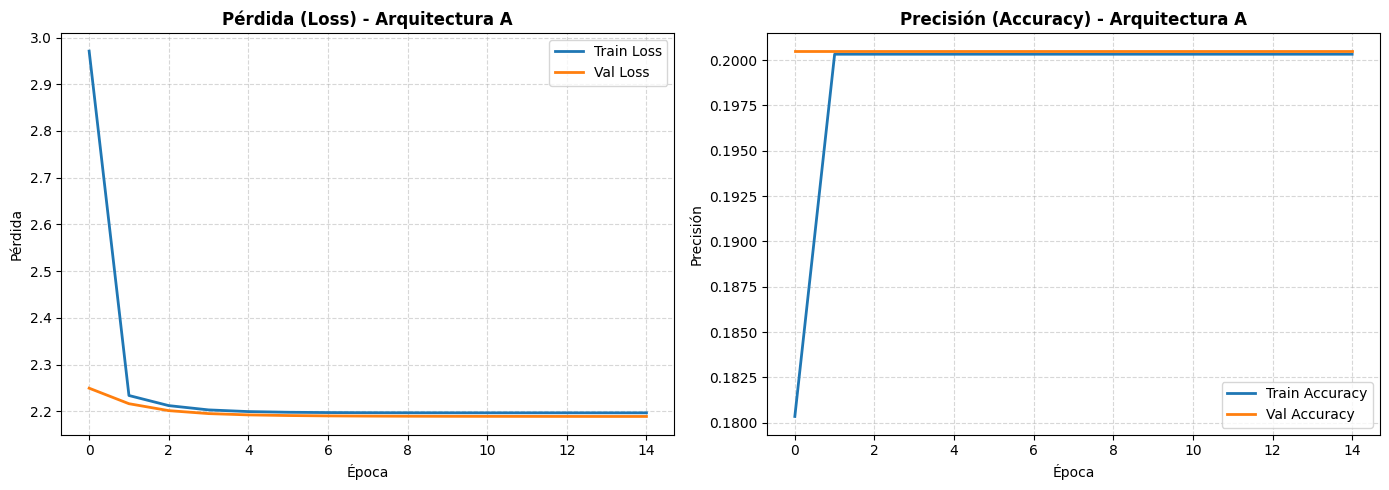

In [79]:
graficar_rendimiento(historia_a, 'Arquitectura A')

Como podemos ver, el grafico nos demuestra que la Arquitectura A no es suficiente para entrenar el modelo, demuestra claramente underfitting, se estaca aproximadamente en la segunda epoca, con un resultado muy deficiente.

#### Grafico de Rendimiento: Arquitectura B

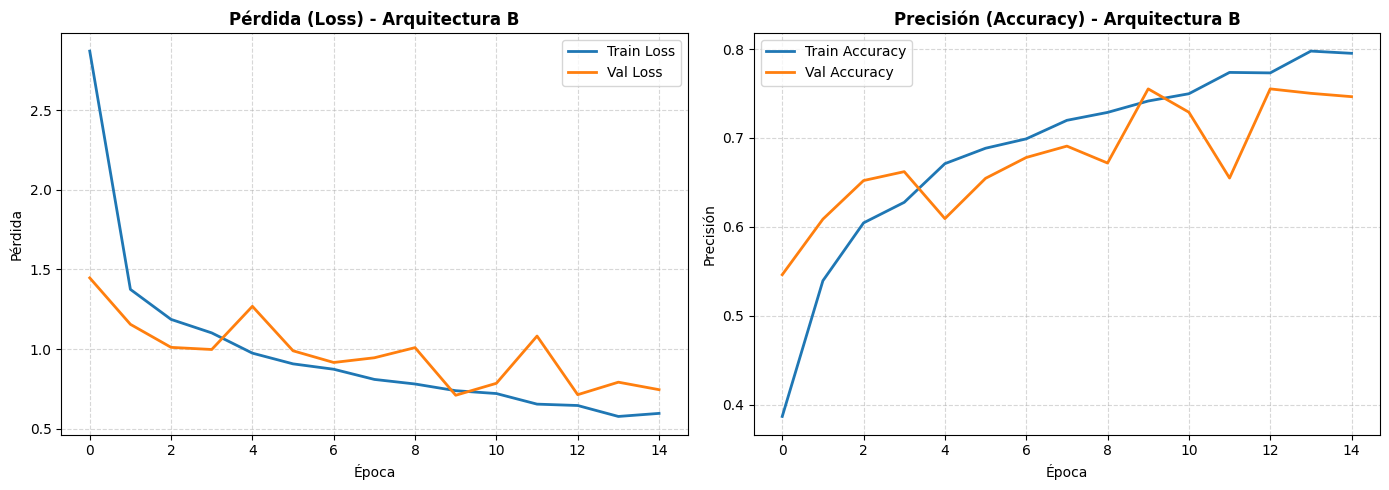

In [80]:
graficar_rendimiento(historia_b, 'Arquitectura B')

Acá podemos ver una increible mejora en comparación a la arquitectura A, no parece tener underfitting u overfitting, aunque tiene algunas epocas que a veces difieren mas de lo usual, el entrenamiento y validación van a la par, progresando de forma adecuada. El resultado es bastante aceptable para haber tenido 15 epocas y poco ajuste de parametros o aplicación de tecnicas mas avanzadas. Es un modelo con buen desempeño gracias a su gran capacidad en su arquitectura.

#### Grafico de Rendimiento: Arquitectura C

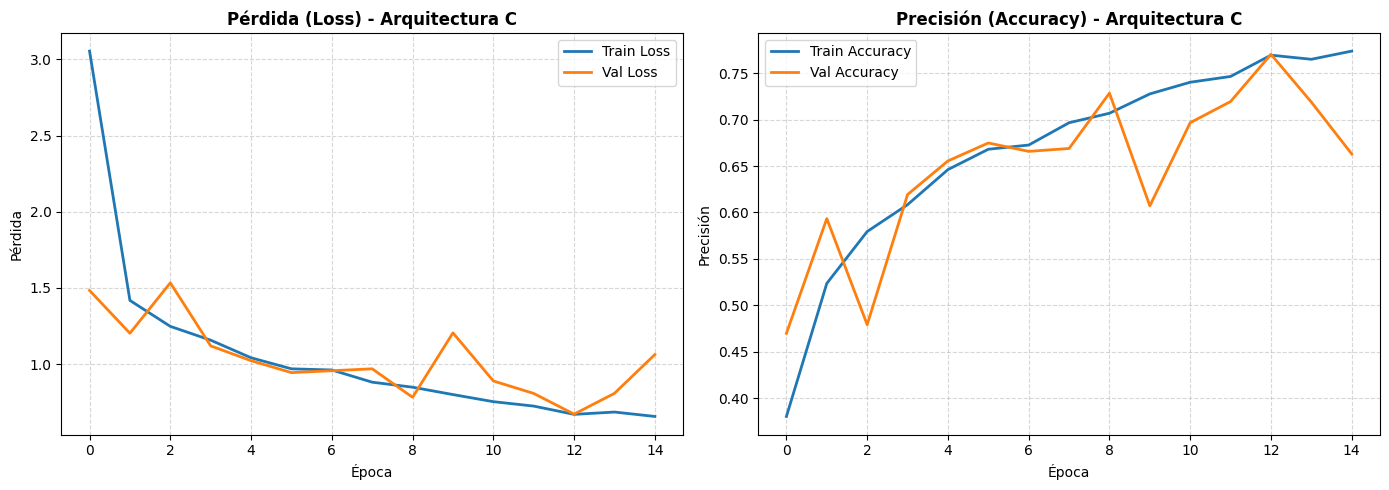

In [81]:
graficar_rendimiento(historia_c, 'Arquitectura C')

Acá la señal es clara, de por si el entrenamiento iba bien hasta la epoca 12, donde parece estar obteniendo overfitting, es probable que empezara a memorizar el entrenamiento en las ultimas epocas, perdiendo la capacidad de generalizar correctamente.

### Predicciones reales (para evaluaciones)

In [126]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    preds = modelo_b.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(y_batch.numpy())

### Matriz de Confusión

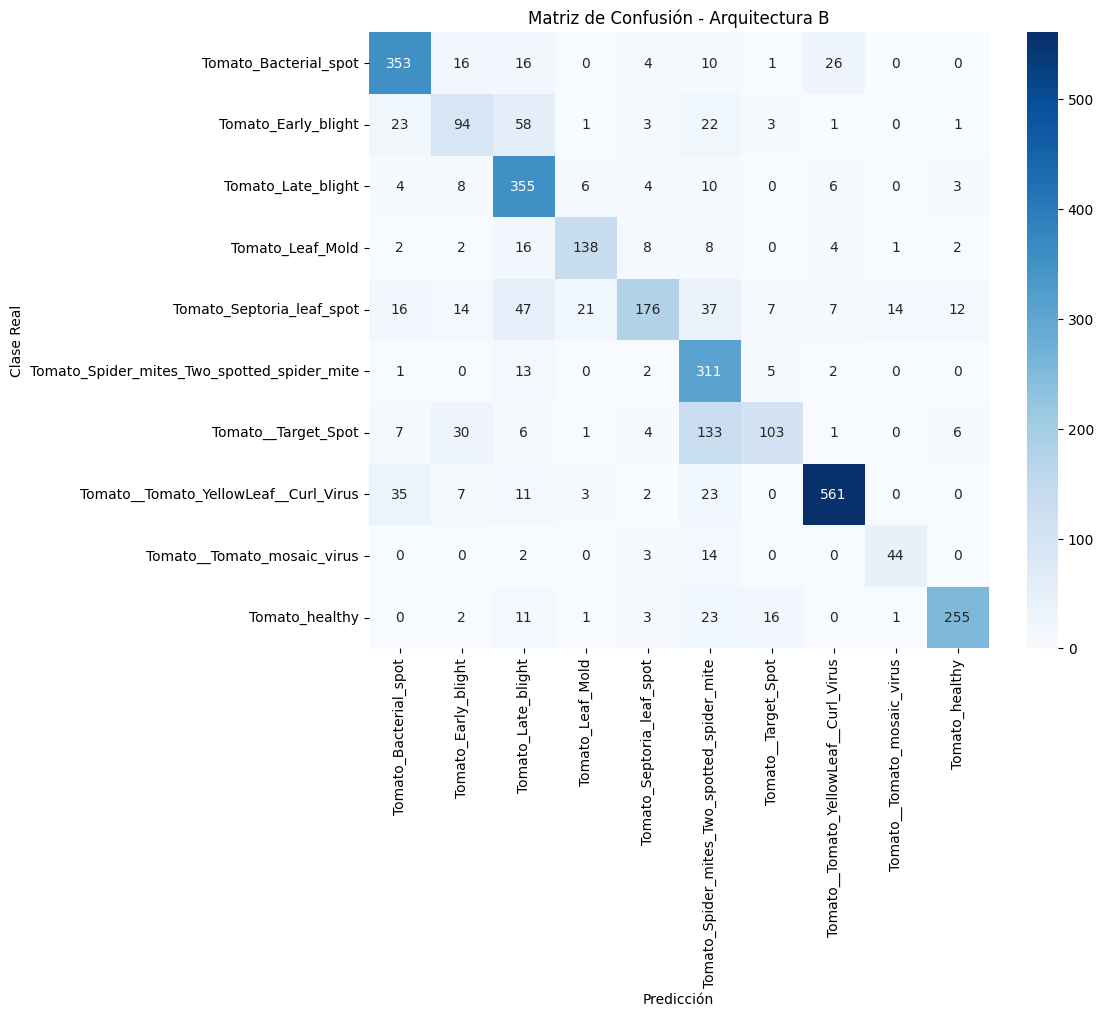

In [127]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clases, yticklabels=clases)
plt.xlabel('Predicción')
plt.ylabel('Clase Real')
plt.title('Matriz de Confusión - Arquitectura B')
plt.xticks(rotation=90)
plt.show()

Con esta matriz, podemos darnos cuenta donde es que el modelo se confunde mas, en este caso parece confundirse mas entre Target_Spot y Spider_Mite (133 confusiones), donde el modelo clasificó Target Spot como Spider Mite. Lo mismo pasó con Early_Blight y Late Blight (58 confusiones), sucedió algo logico dentro de todo, son enfermedades muy similares, al modelo se le dificultó diferenciarlas.

### Reporte de Clasificación

In [128]:
print(classification_report(y_true, y_pred, target_names=clases))

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.80      0.83      0.81       426
                        Tomato_Early_blight       0.54      0.46      0.50       206
                         Tomato_Late_blight       0.66      0.90      0.76       396
                           Tomato_Leaf_Mold       0.81      0.76      0.78       181
                  Tomato_Septoria_leaf_spot       0.84      0.50      0.63       351
Tomato_Spider_mites_Two_spotted_spider_mite       0.53      0.93      0.67       334
                        Tomato__Target_Spot       0.76      0.35      0.48       291
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.92      0.87      0.90       642
                Tomato__Tomato_mosaic_virus       0.73      0.70      0.72        63
                             Tomato_healthy       0.91      0.82      0.86       312

                                   accuracy                    

El reporte de clasificación nos deja claro varias cosas, principalmente es que las clases Tomato__Tomato_YellowLeaf__Curl_Virus (F1-Score de 0.90) y Tomato_healthy (F1-Score de 0.86) tienen un desempeño muy bueno, el modelo puede identificar la planta sana y el virus mas comun en el dataset sin problemas, lo cual es un gran logro. Tambien, por otro lado, el modelo logró aprender sobre las clases minoritarias a pesar de su desbalance en el dataset, como en el caso de  Tomato__Tomato_mosaic_virus que obtuvo un F1-Score de 0.72.

### Prueba de Inferencia Individual

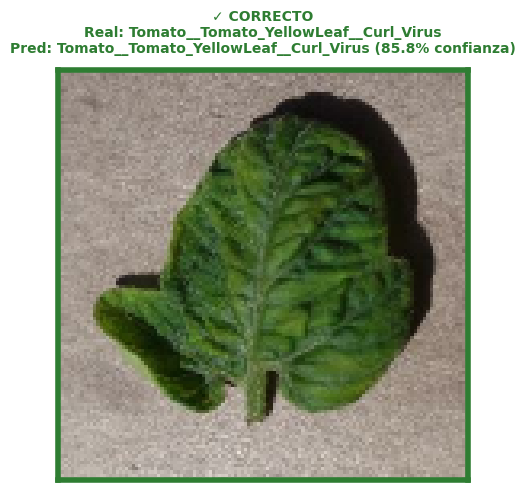

In [134]:
for images, labels in val_ds.take(1):
    img = images[0]
    label_real = clases[labels[0]]

    preds = modelo_b.predict(tf.expand_dims(img, 0), verbose=0)
    pred_class = clases[np.argmax(preds)]
    confianza = np.max(preds) * 100

    es_correcto = label_real == pred_class
    color_tema = "#2e7d32" if es_correcto else "#c62828"
    estado = "✓ CORRECTO" if es_correcto else "✗ INCORRECTO"

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img.numpy().astype("uint8"))

    for spine in ax.spines.values():
        spine.set_edgecolor(color_tema)
        spine.set_linewidth(4)
        spine.set_visible(True)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(
        f"{estado}\nReal: {label_real}\nPred: {pred_class} ({confianza:.1f}% confianza)",
        fontsize=10,
        fontweight="bold",
        color=color_tema,
        pad=12
    )

    plt.tight_layout()
    plt.show()

### Evaluación Final (Los 3 Modelos)

In [130]:
print("="*45)
print(f"{'Arquitectura':<18} | {'Accuracy Final':<15}")
print("="*45)
print(f"{'Modelo A (64)':<18} | {modelo_a.evaluate(val_ds, verbose=0)[1]*100:.2f}%")
print(f"{'Modelo B (512-256-128)':<18} | {modelo_b.evaluate(val_ds, verbose=0)[1]*100:.2f}%")
print(f"{'Modelo C (256-128)':<18} | {modelo_c.evaluate(val_ds, verbose=0)[1]*100:.2f}%")
print("="*45)

Arquitectura       | Accuracy Final 
Modelo A (64)      | 10.52%
Modelo B (512-256-128) | 74.64%
Modelo C (256-128) | 66.30%


De forma oficial seleccionamos el modelo de la arquitectura B como el mejor y el definitivo para la solución del negocio al demostrar mayor accuracy, menor perdida en validación y una capacidad de generalización consistente.